In [1]:
import xarray as xr

ds_GFD_info = xr.open_dataset(
    "outputs/GreenSurge_Tonga_info_updated.nc",
    decode_times=False,
)
ds_GFD_info

<xarray.Dataset> Size: 284kB
Dimensions:                            (element_computation_index: 8657,
                                        triangle_forcing_nodes: 3,
                                        node_forcing_index: 15,
                                        element_forcing_index: 16,
                                        wind_direction_index: 8,
                                        time_forcing_index: 4,
                                        node_cumputation_index: 4553)
Coordinates:
  * element_computation_index          (element_computation_index) int64 69kB ...
  * node_forcing_index                 (node_forcing_index) int64 120B 0 ... 14
  * element_forcing_index              (element_forcing_index) int64 128B 0 ....
  * wind_direction_index               (wind_direction_index) int64 64B 0 ... 7
  * time_forcing_index                 (time_forcing_index) float64 32B 0.0 ....
  * node_cumputation_index             (node_cumputation_index) int64 36kB 0 ...
    node_computation_longitude         (node_cumputation_index) float64 36kB ...
    node_computation_latitude          (node_cumputation_index) float64 36kB ...
    triangle_nodes                     (triangle_forcing_nodes) int64 24B ...
Dimensions without coordinates: triangle_forcing_nodes
Data variables: (12/14)
    triangle_computation_connectivity  (element_computation_index, triangle_forcing_nodes) int32 104kB ...
    node_forcing_longitude             (node_forcing_index) float64 120B ...
    node_forcing_latitude              (node_forcing_index) float64 120B ...
    triangle_forcing_connectivity      (element_forcing_index, triangle_forcing_nodes) int64 384B ...
    wind_directions                    (wind_direction_index) int64 64B ...
    total_elements                     int64 8B ...
    ...                                 ...
    wind_speed                         int64 8B ...
    location_name                      <U5 20B ...
    eddy_viscosity                     int64 8B ...
    chezy_coefficient                  int64 8B ...
    reference_date                     <U19 76B ...
    forcing_time_step                  float64 8B ...
Attributes:
    title:        Hybrid Simulation Input Dataset
    description:  Structured dataset containing simulation parameters for hyb...
    created:      2025-10-19 21:42:17
    institution:  GeoOcean
    model:        GreenSurge
    source:       outputs/GreenSurge_Tonga_info.nc

In [2]:
TCname = "HAROLD2020"
figsize = (6, 5)
instant = [130, 160, 180]

xds_GS_wind = xr.open_dataset(f"outputs/GreenSurge_wind_setup_{TCname}.nc")

ds_WL_dynamic_WindSetUp_UV = xr.open_dataset(
    "inputs/GreenSurge_Tonga_Harold2020_Validation.nc", engine="scipy"
)
ds_WL_dynamic_WindSetUp_UV

<xarray.Dataset> Size: 10MB
Dimensions:            (mesh2d_nEdges: 13225, Two: 2, mesh2d_nFaces: 8657,
                        mesh2d_nMax_face_nodes: 3, mesh2d_nNodes: 4553,
                        time: 261)
Coordinates:
  * time               (time) datetime64[ns] 2kB 2020-04-07 ... 2020-04-09T17...
    mesh2d_edge_x      (mesh2d_nEdges) float32 53kB ...
    mesh2d_edge_y      (mesh2d_nEdges) float32 53kB ...
    mesh2d_face_x      (mesh2d_nFaces) float32 35kB ...
    mesh2d_face_y      (mesh2d_nFaces) float32 35kB ...
    mesh2d_node_x      (mesh2d_nNodes) float32 18kB ...
    mesh2d_node_y      (mesh2d_nNodes) float32 18kB ...
Dimensions without coordinates: mesh2d_nEdges, Two, mesh2d_nFaces,
                                mesh2d_nMax_face_nodes, mesh2d_nNodes
Data variables:
    mesh2d_edge_nodes  (mesh2d_nEdges, Two) int32 106kB ...
    mesh2d_edge_faces  (mesh2d_nEdges, Two) float32 106kB ...
    mesh2d_face_nodes  (mesh2d_nFaces, mesh2d_nMax_face_nodes) float32 104kB ...
    mesh2d_face_x_bnd  (mesh2d_nFaces, mesh2d_nMax_face_nodes) float32 104kB ...
    mesh2d_face_y_bnd  (mesh2d_nFaces, mesh2d_nMax_face_nodes) float32 104kB ...
    mesh2d_node_z      (mesh2d_nNodes) float32 18kB ...
    mesh2d_s1          (time, mesh2d_nFaces) float32 9MB ...
    mesh2d             int32 4B ...
Attributes: (12/18)
    institution:               Deltares
    references:                https://www.deltares.nl
    source:                    D-Flow FM 1.2.184.Unknown. Model:
    history:                   Created on 2025-10-14T12:55:24-0000, D-Flow FM
    date_created:              2025-10-14T12:55:24-0000
    date_modified:             2025-10-14T12:55:24-0000
    ...                        ...
    geospatial_lon_max:        -174.744455622
    geospatial_lon_units:      degrees_east
    time_coverage_start:       2020-04-07T00:00:00+00:00
    time_coverage_end:         2020-04-09T17:00:00+00:00
    time_coverage_duration:    P0000-00-02T17:00:00
    time_coverage_resolution:  P0000-00-00T00:15:00

<div style="border: 1px solid #cce5ff; background-color: #e9f7fe; padding: 15px; border-radius: 6px; font-family: sans-serif;">
  <strong>🔹 Model validation</strong><br><br>

  The figures below show the maps of a given time and the swath maps of wind setup resulting from dynamic simulations with the Shallow Water Equation (SWE) model Delft3DFM (left panels) and from the GreenSurge aproach (right panels). These figures illustrate the importance of the wind setup in shallow water areas close to shore and de acuracy of the GreenSurge approach compared to dynamic simulations.
</div>

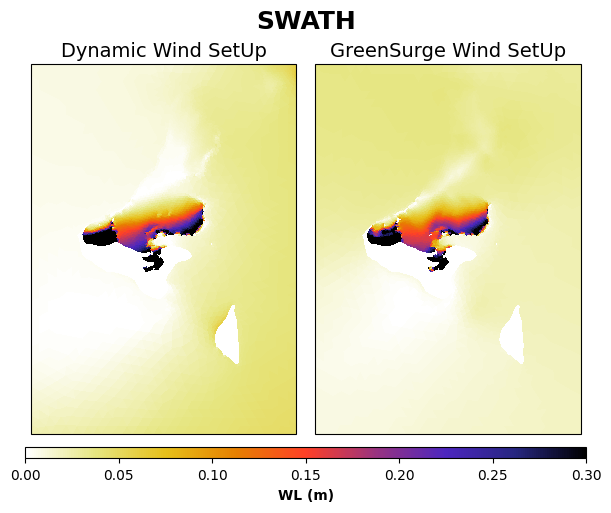

In [3]:
from bluemath_tk.additive.greensurge import plot_GS_vs_dynamic_windsetup_swath

plot_GS_vs_dynamic_windsetup_swath(
    ds_WL_GS_WindSetUp=xds_GS_wind,
    ds_WL_dynamic_WindSetUp=ds_WL_dynamic_WindSetUp_UV,
    ds_gfd_metadata=ds_GFD_info,
    vmin=0,
    vmax=0.3,
    figsize=figsize,
);

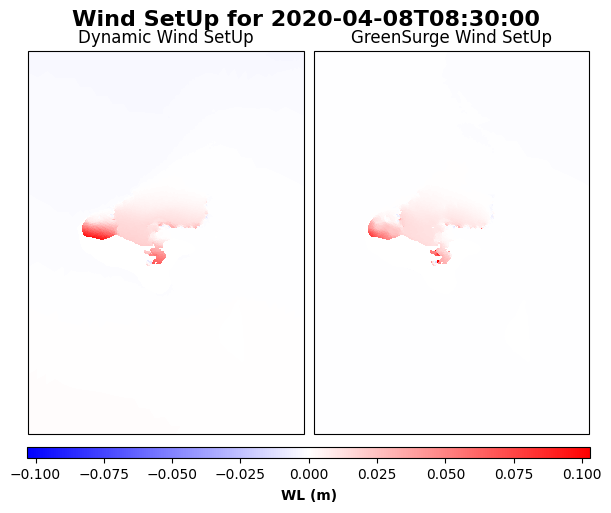

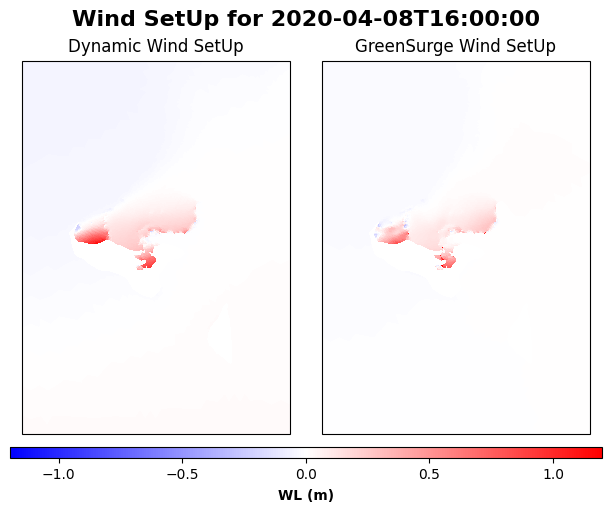

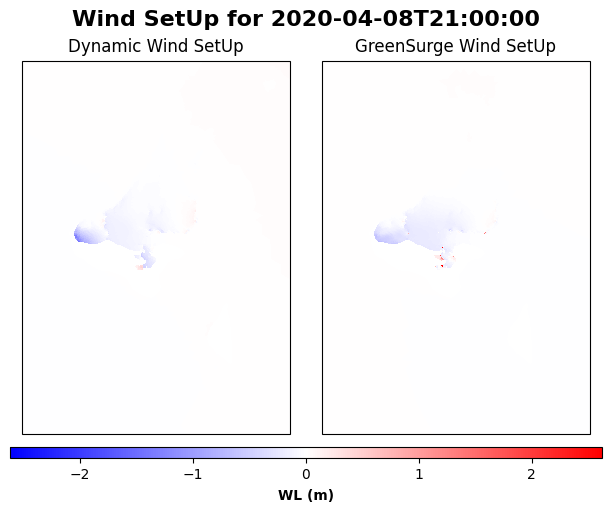

In [4]:
from bluemath_tk.additive.greensurge import plot_GS_vs_dynamic_windsetup

for i in instant:
    plot_GS_vs_dynamic_windsetup(
        ds_WL_GS_WindSetUp=xds_GS_wind,
        ds_WL_dynamic_WindSetUp=ds_WL_dynamic_WindSetUp_UV,
        ds_gfd_metadata=ds_GFD_info,
        time=ds_WL_dynamic_WindSetUp_UV.time[i].values,
        figsize=figsize,
    )

<div style="border: 1px solid #cce5ff; background-color: #e9f7fe; padding: 15px; border-radius: 6px; font-family: sans-serif;">
  <strong>🔹 Inverse Barometer</strong><br><br>

  The third stage for any TC event study consist of turning pressure differences into sea level rises and falls using IB methodology which take into account the correlation 1mb-1cm.
</div>


In [5]:
from bluemath_tk.additive.greensurge import pressure_to_IB

xds_vortex_GS = xr.open_dataset(
    f"outputs/GreenSurge_vortex_{TCname}.nc",
)

ds_WL_GS_IB = pressure_to_IB(xds_presure=xds_vortex_GS)

<div style="border: 1px solid #cce5ff; background-color: #e9f7fe; padding: 15px; border-radius: 6px; font-family: sans-serif;">
  <strong>🔹 Storm Surge</strong><br><br>

  Finally the fourth stage sums both components, the wind setup and the pressure-induced sea level changes, to obtain the storm surge.
  $$
  \eta_{SS} = \eta_{WindSetUp} + \eta_{IB}
  $$

</div>

<div style="border: 1px solid #cce5ff; background-color: #e9f7fe; padding: 15px; border-radius: 6px; font-family: sans-serif;">
  <strong>🔹 Model validation</strong><br><br>

  The panel below shows timeseries comparison of windsetup at three given locations. These figures illustrate the acuracy of Greensurge approach compared to dynamic simulations.
</div>

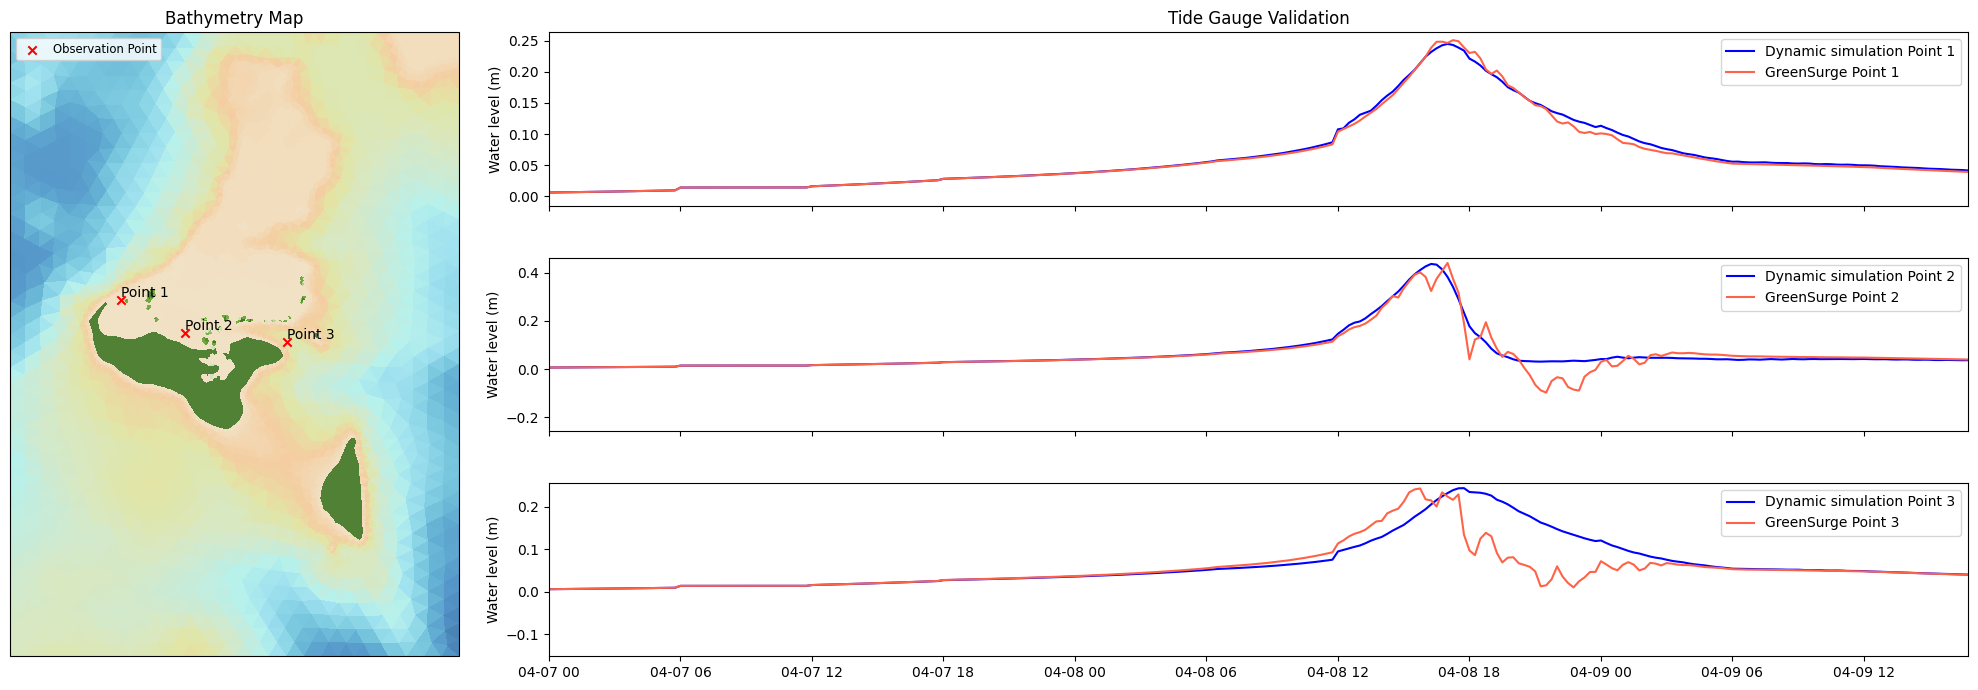

In [6]:
from bluemath_tk.additive.greensurge import plot_GS_validation_timeseries

plot_GS_validation_timeseries(
    ds_WL_GS_WindSetUp=xds_GS_wind,
    ds_WL_GS_IB=ds_WL_GS_IB,
    ds_WL_dynamic_WindSetUp=ds_WL_dynamic_WindSetUp_UV,
    ds_GFD_info=ds_GFD_info,
    lon_obs=[-175.30200513384034, -175.1955377589225, -175.02734416274885],
    lat_obs=[-21.059426057898943, -21.11369542021114, -21.129023408039775],
)